# Delivery Performance Audit for Veridi Logistics

## Business Problem

Veridi Logistics wants to determine whether customer dissatisfaction is caused by inaccurate delivery estimates and delayed deliveries. This project combines logistics, customer review, and product data to identify the root causes of poor customer experience.

In [ ]:
# Importing python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ns
print('all python labraries loaded succsuccessfully ')

all python labraries loaded succsuccessfully 


## Story 1: Schema Builder

The objective of this task is to combine orders, customers, and review data into a single master dataset that can be used for integrated logistics and customer satisfaction analysis.

In [ ]:
# loading the datasets
customers = pd.read_csv('/content/olist_customers_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')
orders = pd.read_csv('/content/olist_orders_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
translation = pd.read_csv('/content/product_category_name_translation.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
print('datasets loaded succsuccessfully')

datasets loaded succsuccessfully


## Data Exploration

The datasets were explored to understand their structure, identify key variables, inspect data types, and assess data quality before integration and analysis.

In [ ]:
# exploriexploring the datasets
print('customers:', customers.shape)
print('reviews:', reviews.shape)
print('orders:', orders.shape)
print('products:', products.shape)
print('translation:', translation.shape)

customers: (99441, 5)
reviews: (99224, 7)
orders: (99441, 8)
products: (32951, 9)
translation: (71, 2)


In [ ]:
# Checking for duplicate rows in each dataset

print("Customers duplicates:", customers.duplicated().sum())
print("Reviews duplicates:", reviews.duplicated().sum())
print("Orders duplicates:", orders.duplicated().sum())
print("Products duplicates:", products.duplicated().sum())
print("Translation duplicates:", translation.duplicated().sum())

Customers duplicates: 0
Reviews duplicates: 0
Orders duplicates: 0
Products duplicates: 0
Translation duplicates: 0


In [ ]:
 # exploriexploring the datasets
 customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,1/18/2018 0:00,1/18/2018 21:46
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,3/10/2018 0:00,3/11/2018 3:05
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2/17/2018 0:00,2/18/2018 14:36
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,4/21/2017 0:00,4/21/2017 22:02
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,3/1/2018 0:00,3/2/2018 10:26


In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,10/2/2017 10:56,10/2/2017 11:07,10/4/2017 19:55,10/10/2017 21:25,10/18/2017 0:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,7/24/2018 20:41,7/26/2018 3:24,7/26/2018 14:31,8/7/2018 15:27,8/13/2018 0:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,8/8/2018 8:38,8/8/2018 8:55,8/8/2018 13:50,8/17/2018 18:06,9/4/2018 0:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,11/18/2017 19:28,11/18/2017 19:45,11/22/2017 13:39,12/2/2017 0:28,12/15/2017 0:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2/13/2018 21:18,2/13/2018 22:20,2/14/2018 19:46,2/16/2018 18:17,2/26/2018 0:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
# data cleaning
# Converting Order Dates to Datetime
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
  orders[col] = pd.to_datetime(orders[col])
  print("Date columns converted successfully!")

Date columns converted successfully!
Date columns converted successfully!
Date columns converted successfully!
Date columns converted successfully!
Date columns converted successfully!


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


## Building the Master Dataset

Orders, customer information, and review data were merged into a single analytical dataset. This integrated dataset serves as the foundation for all subsequent delivery performance and customer satisfaction analyses.

In [ ]:
## Story 1: Building the Master Dataset
orders_customers = pd.merge(   # merging orders and customers tables
    orders,
    customers,
    on = 'customer_id',
    how = 'left'
)
orders_customers.shape

(99441, 12)

In [ ]:
master_df = pd.merge(     # merging orders_customers and reviews
    orders_customers,
    reviews,
    on = 'order_id',
    how = 'left'
)
master_df.shape

(99992, 18)

In [ ]:
master_df['order_id'].nunique()

99441

In [ ]:
reviews['order_id'].duplicated().sum()

np.int64(551)

In [ ]:
# Remove duplicate reviews before merging
reviews_clean = reviews.drop_duplicates(
    subset = 'order_id',
    keep = 'first'
)
reviews_clean.shape

(98673, 7)

In [ ]:
reviews_clean['order_id'].duplicated().sum()

np.int64(0)

In [ ]:
master_df = pd.merge(
    orders_customers,
    reviews_clean,
    on = 'order_id',
    how = 'left'
)
master_df.shape

(99441, 18)

In [ ]:
master_df['order_id'].nunique()


99441

In [ ]:
master_df['order_id'].duplicated().sum()

np.int64(0)

## Story 2: Real Delay Calculator

This analysis calculates the difference between estimated and actual delivery dates and classifies orders into On Time, Late, Super Late, and Not Delivered categories.

In [ ]:
## Story 2: The "Real" Delay Calculator
#Checking Missing Delivery Dates
master_df['order_delivered_customer_date'].isnull().sum()


np.int64(2965)

In [ ]:
master_df['order_estimated_delivery_date'].isnull().sum()

np.int64(0)

In [ ]:
#Creating the Days_Difference Column
master_df['Days_difference'] = (
    master_df['order_estimated_delivery_date'] -
    master_df['order_delivered_customer_date']
).dt.days

In [ ]:
master_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,Days_difference
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",10/11/2017 0:00,10/12/2017 3:43,7.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,8/8/2018 0:00,8/8/2018 18:37,5.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,8/18/2018 0:00,8/22/2018 19:07,17.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,12/3/2017 0:00,12/5/2017 19:21,12.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2/17/2018 0:00,2/18/2018 13:02,9.0


In [ ]:
master_df[['order_estimated_delivery_date',
           'order_delivered_customer_date',
           'Days_difference']].head()

,order_estimated_delivery_date,order_delivered_customer_date,Days_difference
0,2017-10-18,2017-10-10 21:25:00,7.0
1,2018-08-13,2018-08-07 15:27:00,5.0
2,2018-09-04,2018-08-17 18:06:00,17.0
3,2017-12-15,2017-12-02 00:28:00,12.0
4,2018-02-26,2018-02-16 18:17:00,9.0


In [ ]:
# Creating Delivery Status
def classify_delivery(days):
  if pd.isna(days):
    return 'Not Delivered'
  elif days >= 0:
    return 'On Time'
  elif days >= -5:
    return 'Late'
  else:
    return 'Super Late'
master_df['Delivery_Status'] = master_df['Days_difference'].apply(classify_delivery)

In [ ]:
master_df['Delivery_Status'].value_counts()

,count
Delivery_Status,
On Time,88649
Super Late,4212
Late,3615
Not Delivered,2965


In [ ]:
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'Days_difference', 'Delivery_Status'],
      dtype='object')

## Story 3: Geographic Analysis

### Objective
This analysis identifies the states with the highest percentage of late deliveries to determine whether delivery performance varies geographically.

### Business Question
Are certain regions experiencing significantly more delivery delays than others?

In [ ]:
# We want to group Late and Super Late together
master_df['Late_Flag'] = master_df['Delivery_Status'].isin(
    ['Late', 'Super Late']
)

In [ ]:
# Calculate Late Deliveries by State
State_Late = master_df.groupby('customer_state')['Late_Flag'].mean()*100
State_Late = State_Late.sort_values(ascending=False)
State_Late.head()

,Late_Flag
customer_state,
AL,23.002421
MA,18.875502
PI,15.353535
CE,14.670659
SE,14.571429


In [ ]:
# Creating a clean dataset for delivery analysis
analysis_df = master_df[
    master_df['Delivery_Status'] != 'Not Delivered'
]
analysis_df.shape


(96476, 21)

In [ ]:
analysis_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'Days_difference', 'Delivery_Status',
       'Late_Flag'],
      dtype='object')

In [ ]:
# Calculating the % of late orders per State.
State_Late = (
    analysis_df
    .groupby('customer_state')['Late_Flag']
    .mean()*100
).sort_values(ascending = False)
State_Late.head(10)

,Late_Flag
customer_state,
AL,23.929471
MA,19.665272
PI,15.966387
CE,15.324472
SE,15.223881
BA,14.035627
RJ,13.470412
TO,12.773723
PA,12.367865


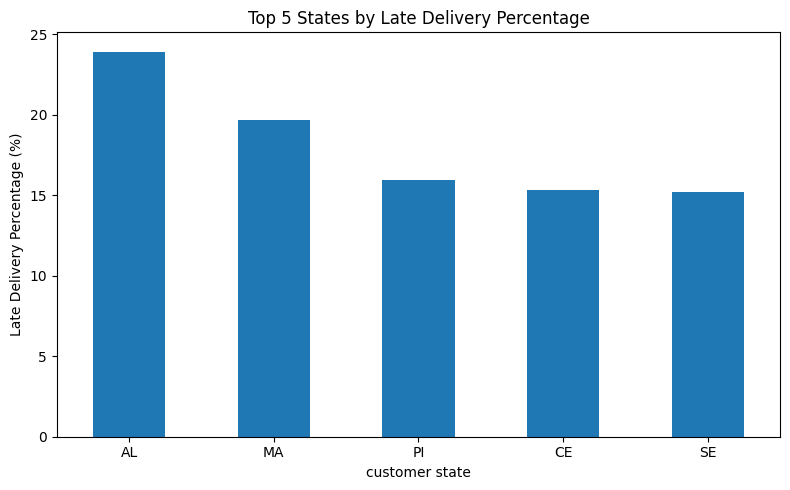

In [ ]:
# Creating the Chart
top10_states = State_Late.head(5)
plt.figure(figsize=(8,5))
top10_states.plot(kind = 'bar')
plt.title('Top 5 States by Late Delivery Percentage')
plt.xlabel('customer state')
plt.ylabel('Late Delivery Percentage (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig
plt.show()


### Insight
States such as AL, MA, and PI recorded the highest late-delivery rates. While the dataset does not contain warehouse or distance information, the concentration of delays in certain regions suggests that geographic and logistical factors may be contributing to delivery performance issues.


## Story 4: Sentiment Correlation

This analysis investigates whether delivery delays negatively affect customer review scores.

In [ ]:
# Comparing Average Review Scores by Delivery Status
master_df.groupby('Delivery_Status')['review_score'].mean()

,review_score
Delivery_Status,
Late,3.459361
Not Delivered,1.751671
On Time,4.294358
Super Late,1.786517


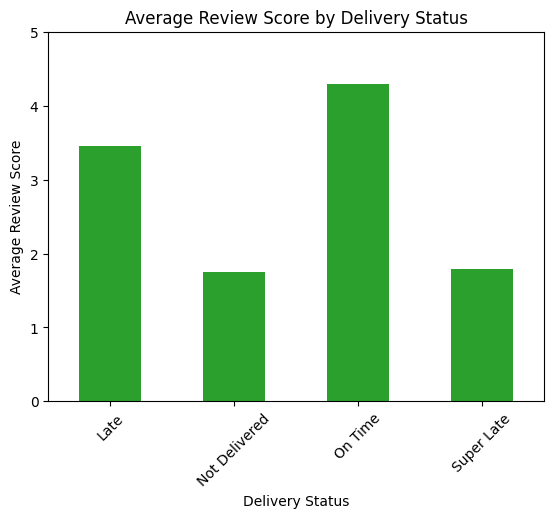

In [ ]:
Avg_reviews = master_df.groupby('Delivery_Status')['review_score'].mean()
Avg_reviews.plot(kind = 'bar',
                 color='#2ca02c')
plt.title('Average Review Score by Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0,5)
plt.xticks(rotation = 45)
plt.show()

In [ ]:
review_comparison = master_df[
    master_df['Delivery_Status'].isin(['On Time', 'Late'])
]

review_comparison.groupby('Delivery_Status')['review_score'].mean()

,review_score
Delivery_Status,
Late,3.459361
On Time,4.294358


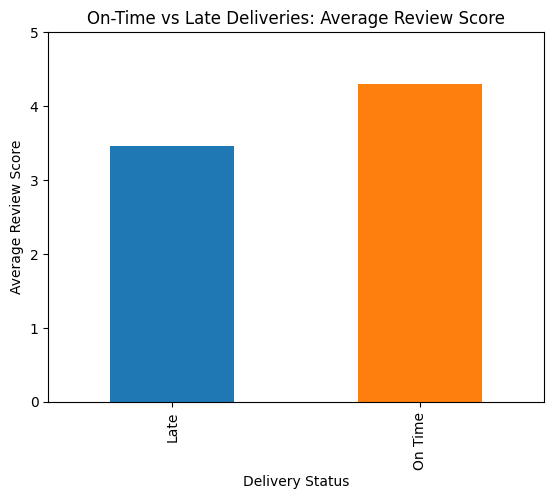

In [ ]:
review_comparison.groupby('Delivery_Status')['review_score'].mean().plot(
    kind='bar',
    color=['#1f77b4', '#ff7f0e']
)

plt.title('On-Time vs Late Deliveries: Average Review Score')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0,5)

plt.show()

## Story 5: Product Category Translation and Analysis

Product categories are translated from Portuguese to English to support business analysis and identify categories with the highest late-delivery rates.

In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
# merging order_items with master_df
master_df = pd.merge(
    master_df,
    order_items,
    on = 'order_id',
    how = 'left'
)
master_df.shape

(113425, 27)

In [ ]:
master_df['order_id'].nunique()

99441

In [ ]:
order_items['order_id'].nunique()

98666

In [ ]:
# Merge Products tables
master_df = pd.merge(
    master_df,
    products,
    on = 'product_id',
    how = 'left'
)
master_df.shape

(113425, 35)

In [ ]:
# merging translation table
master_df = pd.merge(
    master_df,
    translation,
    on='product_category_name',
    how='left'
)

master_df.shape

(113425, 36)

In [ ]:
master_df[
    ['product_category_name',
     'product_category_name_english']
].head()

,product_category_name,product_category_name_english
0,utilidades_domesticas,housewares
1,perfumaria,perfumery
2,automotivo,auto
3,pet_shop,pet_shop
4,papelaria,stationery


In [ ]:
# Calculating Late Delivery Rate by Product Category
category_late_rate = (
    master_df.groupby('product_category_name_english')['Late_Flag']
    .mean()
    .sort_values(ascending= False)*100
)
category_late_rate.head(10)

,Late_Flag
product_category_name_english,
home_comfort_2,16.666667
furniture_mattress_and_upholstery,13.157895
audio,12.637363
fashion_underwear_beach,12.213740
christmas_supplies,11.764706
books_technical,10.861423
home_confort,10.138249
construction_tools_lights,9.868421
electronics,9.613300


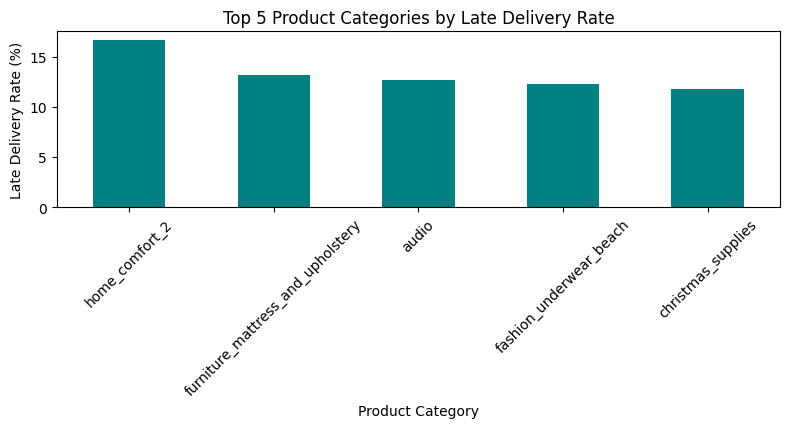

In [ ]:
# Visualizing the Top 5
top5 = category_late_rate.head(5)
plt.figure(figsize=(8,5))
top5.plot(kind= 'bar',
          color='teal')
plt. title('Top 5 Product Categories by Late Delivery Rate')
plt.ylabel('Late Delivery Rate (%)')
plt.xlabel('Product Category')
plt.tight_layout()
plt.xticks(rotation= 45)
plt.show()

## Candidate's Choice Challenge: Freight Cost vs Delivery Delay

This analysis examines whether higher shipping costs result in improved delivery performance.

In [ ]:
## Bonus Analysis: Freight Cost vs Delivery Delay
master_df[['freight_value', 'Days_difference']].head()

,freight_value,Days_difference
0,8.72,7.0
1,22.76,5.0
2,19.22,17.0
3,27.20,12.0
4,8.72,9.0


In [ ]:
master_df[['freight_value', 'Days_difference']].isnull().sum()

,0
freight_value,775
Days_difference,3229


In [ ]:
# Creating a dataset that contains only the columns needed
# for the bonus analysis

bonus_df = master_df[['freight_value', 'Days_difference']].dropna()

bonus_df.shape

(110196, 2)

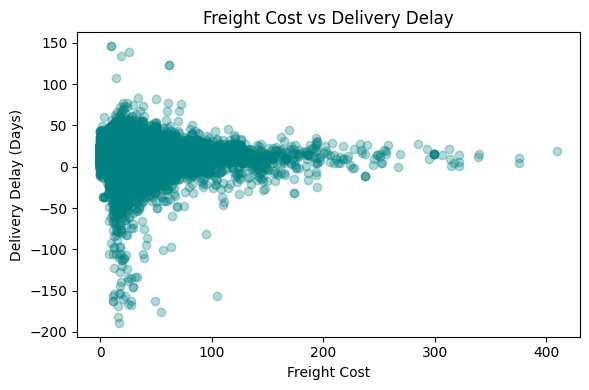

In [ ]:
# Visualizing the relationship between freight cost
# and delivery delay

plt.figure(figsize=(6,4))

plt.scatter(
    bonus_df['freight_value'],
    bonus_df['Days_difference'],
    alpha=0.3,
    color='teal'
)

plt.title('Freight Cost vs Delivery Delay')
plt.xlabel('Freight Cost')
plt.ylabel('Delivery Delay (Days)')

plt.tight_layout()
plt.show()

In [ ]:
# Measuring the relationship between freight cost
# and delivery delay

correlation = bonus_df['freight_value'].corr(
    bonus_df['Days_difference']
)

print("Correlation:", correlation)

Correlation: 0.04024203581997367


In [ ]:
# saving my final master_df
master_df.to_csv('final_logistics_dataset.csv', index=False)

In [ ]:
from google.colab import files
files.download('final_logistics_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Final dataset shape
master_df.shape

(113425, 36)

In [ ]:
# Final column names
master_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'Days_difference', 'Delivery_Status',
       'Late_Flag', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english'],
      dtype='object')

In [ ]:
# Missing values summary
master_df.isnull().sum().sort_values(ascending=False).head(10)

,0
review_comment_title,99920
review_comment_message,65497
Days_difference,3229
order_delivered_customer_date,3229
product_category_name_english,2402
product_photos_qty,2378
product_category_name,2378
product_name_lenght,2378
product_description_lenght,2378
order_delivered_carrier_date,1968


## Final Dataset Export

The final cleaned dataset was exported for dashboard development and further business reporting.

## Key Findings

1. Delivery delays vary significantly across states.
2. On-time deliveries receive substantially higher review scores.
3. Furniture-related products experience higher late-delivery rates.
4. Freight cost has almost no relationship with delivery delays (r = 0.04).
5. Logistics performance is a major driver of customer satisfaction.

## Conclusion

The analysis demonstrates that delivery delays are a key contributor to negative customer reviews. Regional differences, product characteristics, and operational inefficiencies appear to influence delivery performance more strongly than shipping expenditure. Improving delivery reliability is likely to increase customer satisfaction and strengthen Veridi Logistics' overall service quality.